In [1]:
import os
from glob import glob
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split

# ---------------------------------------------------------
# 1. 커스텀 데이터셋 (변경 없음)
# ---------------------------------------------------------
class LeapGestureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        self.classes = sorted([
            '01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb',
            '06_index', '07_ok', '08_palm_moved', '09_c', '10_down'
        ])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for img_path in glob(os.path.join(root_dir, '*', '*', '*.png')):
            gesture_name = os.path.basename(os.path.dirname(img_path))
            if gesture_name in self.class_to_idx:
                self.image_paths.append(img_path)
                self.labels.append(self.class_to_idx[gesture_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB') 
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# ---------------------------------------------------------
# 2. 설정 (변경 없음)
# ---------------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"현재 구동 중인 디바이스: {device}")

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 3. 데이터 로드 (변경 없음)
# ---------------------------------------------------------
data_dir = './leapGestRecog' 

print("데이터를 불러오는 중...")
full_dataset = LeapGestureDataset(root_dir=data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# ★ 4. 모델 설정 (파인튜닝 전략 적용) ★
# ---------------------------------------------------------
print("사전 학습된 EfficientNet-B0를 불러옵니다...")
# 1. ImageNet으로 학습된 가중치를 다운로드하여 적용
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 2. 특징 추출기(몸통)의 파라미터를 모두 얼림 (학습 안 함)
for param in model.parameters():
    param.requires_grad = False

# 3. 마지막 분류기만 10개 클래스에 맞게 새로 교체 
# (새로 만들어진 층은 자동으로 requires_grad=True 가 되어 학습 가능해집니다)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# 4. ★ 옵티마이저: 얼어있는 몸통은 놔두고, 오직 '새로 단 분류기'만 학습하도록 설정
optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

# ---------------------------------------------------------
# 5. 본격적인 학습 및 검증 루프 (동일)
# ---------------------------------------------------------
print("\n--- 학습 시작 ---")
for epoch in range(1, EPOCHS + 1):
    
    model.train()
    running_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = 100. * val_correct / val_total
    
    print(f"Epoch [{epoch:2d}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("--- 학습 완료 ---")

현재 구동 중인 디바이스: mps
데이터를 불러오는 중...
사전 학습된 EfficientNet-B0를 불러옵니다...

--- 학습 시작 ---
Epoch [ 1/10] | Train Loss: 0.6351 | Train Acc: 88.43% | Val Acc: 98.75%
Epoch [ 2/10] | Train Loss: 0.2159 | Train Acc: 95.84% | Val Acc: 99.15%
Epoch [ 3/10] | Train Loss: 0.1474 | Train Acc: 96.96% | Val Acc: 99.40%
Epoch [ 4/10] | Train Loss: 0.1218 | Train Acc: 97.21% | Val Acc: 99.58%
Epoch [ 5/10] | Train Loss: 0.1017 | Train Acc: 97.63% | Val Acc: 99.58%
Epoch [ 6/10] | Train Loss: 0.0949 | Train Acc: 97.71% | Val Acc: 99.58%
Epoch [ 7/10] | Train Loss: 0.0833 | Train Acc: 97.96% | Val Acc: 99.72%
Epoch [ 8/10] | Train Loss: 0.0769 | Train Acc: 98.04% | Val Acc: 99.60%
Epoch [ 9/10] | Train Loss: 0.0674 | Train Acc: 98.20% | Val Acc: 99.70%
Epoch [10/10] | Train Loss: 0.0677 | Train Acc: 98.21% | Val Acc: 99.70%
--- 학습 완료 ---


혼동 행렬을 계산하기 위해 검증 데이터를 분석합니다...


/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykernel_13620/4240745254.py:43: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykernel_13620/4240745254.py:43: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykernel_13620/4240745254.py:43: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykernel_13620/4240745254.py:43: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykernel_13620/4240745254.py:43: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pg/t40j_v2s3yx3v2tggldjd3yw0000gn/T/ipykerne

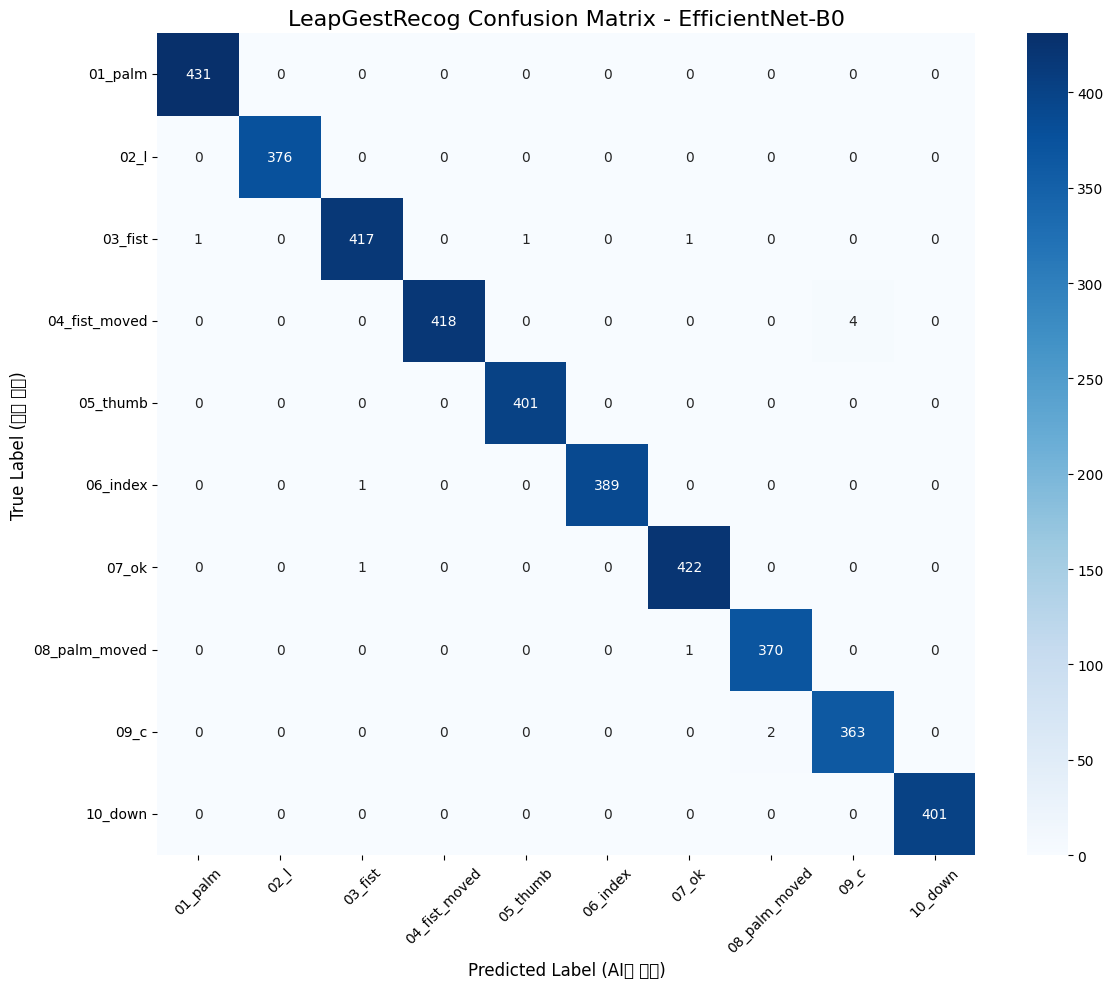

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("혼동 행렬을 계산하기 위해 검증 데이터를 분석합니다...")

# 1. 모델을 평가 모드로 전환 (Dropout 등 비활성화)
model.eval()

all_preds = []
all_labels = []

# 2. 검증 데이터 전체에 대한 예측값과 실제 정답 수집
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = outputs.max(1)
        
        # GPU/MPS 텐서를 CPU로 내리고 numpy 배열로 변환하여 리스트에 추가
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 혼동 행렬(Confusion Matrix) 계산
cm = confusion_matrix(all_labels, all_preds)

# 4. 클래스 이름 가져오기 (01_palm, 02_l, ...)
class_names = full_dataset.classes

# 5. Seaborn을 사용한 우아한 시각화
plt.figure(figsize=(12, 10))
# fmt='d'는 정수 형태 출력, cmap='Blues'는 파란색 계열 열지도 적용
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('LeapGestRecog Confusion Matrix - EfficientNet-B0', fontsize=16)
plt.ylabel('True Label (실제 정답)', fontsize=12)
plt.xlabel('Predicted Label (AI의 예측)', fontsize=12)
plt.xticks(rotation=45) # X축 글씨가 겹치지 않게 45도 기울임
plt.tight_layout()
plt.show()